# Aula 2 - Imagens Matriciais
## Representação

Também chamadas de **bitmaps**, as imagens matriciais são formas de representar imagens a partir de pixels.

Definições:
* **Pixel**: menor elemento que compõe uma imagem digital;
* **Bitmap**: **matriz de pixels** (tradução: mapa de bits);
* **Profundidade de bit**: quantidade de **bits por pixel** (bpp);
* **Resolução**: dimensões da imagem, normalmente expressa em **largura × altura**.

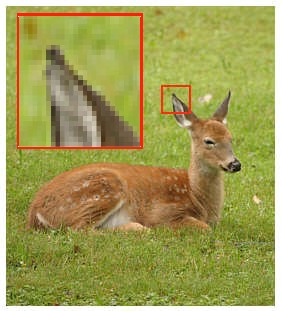

## Manipulação
* Ler imagem do disco e salvar em uma variável:

In [2]:
# PIL (Python Image Library) é utilizada para operações
# básicas em imagens:
from PIL import Image

In [3]:
img = Image.open('link.jpg')

* Exibir uma imagem:

In [4]:
# Matplotlib é utilizada para exibir imagens e gráficos:
import matplotlib.pyplot as plt

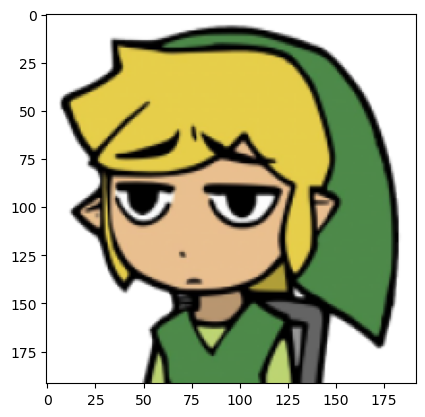

In [5]:
plt.imshow(img)

* Salvar uma imagem em um arquivo:

In [6]:
img.save('link.png')
type(img)

PIL.PngImagePlugin.PngImageFile

* Converter Image do PIL para Array do NumPy:

In [7]:
import numpy as np

(192, 192, 3)


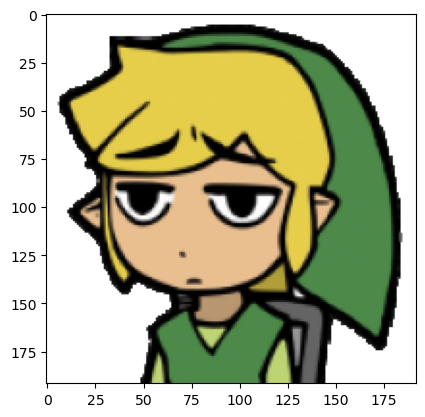

In [ ]:
img_np = np.array(img)
# img_np é um array numpy com as informações da imagem onde [altura, largura, canais de cor (RGBA)] 
img_np2 = img_np[:,:,:3] #tirar o canal alfa onde :3 significa pegar os 3 primeiros canais (R, G, B)
plt.imshow(img_np2)
print(img_np2.shape)

* Converter Array para Image:

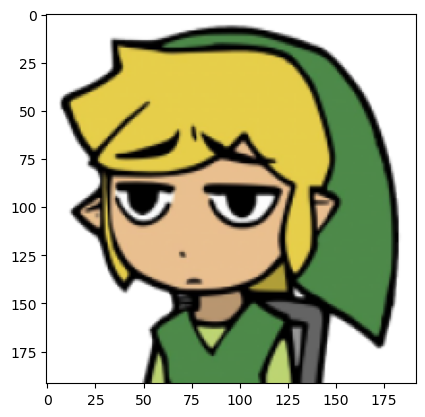

In [12]:
img_pil = Image.fromarray(img_np)
plt.imshow(img_pil)

#### Resumindo:
* Importar bibliotecas:
```python
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
```
* Ler/gravar/converter imagens:
```python
img = Image.open('imagem.extensao')
plt.imshow(img)
img_np = np.array(img)
img_pil = Image.fromarray(img_np)
img.save('imagem.extensao')
```

## RGB
* O espaço de cores RGB apresenta **três canais de cores (Red, Green, Blue) por pixel**, sendo uma cor representada como a combinação destes três canais.
* Adicionalmente, pode conter um canal A (alpha) representando transparência.
* Imagens RGB normalmente têm profundidade de **24 bpp**, isto é, **8 bits por canal**. Com isso, cada canal pode ter até 256 valores possíveis (0~255).
* Uma imagem com profundidade de 24 bpp ou mais é chamada de **truecolor**.
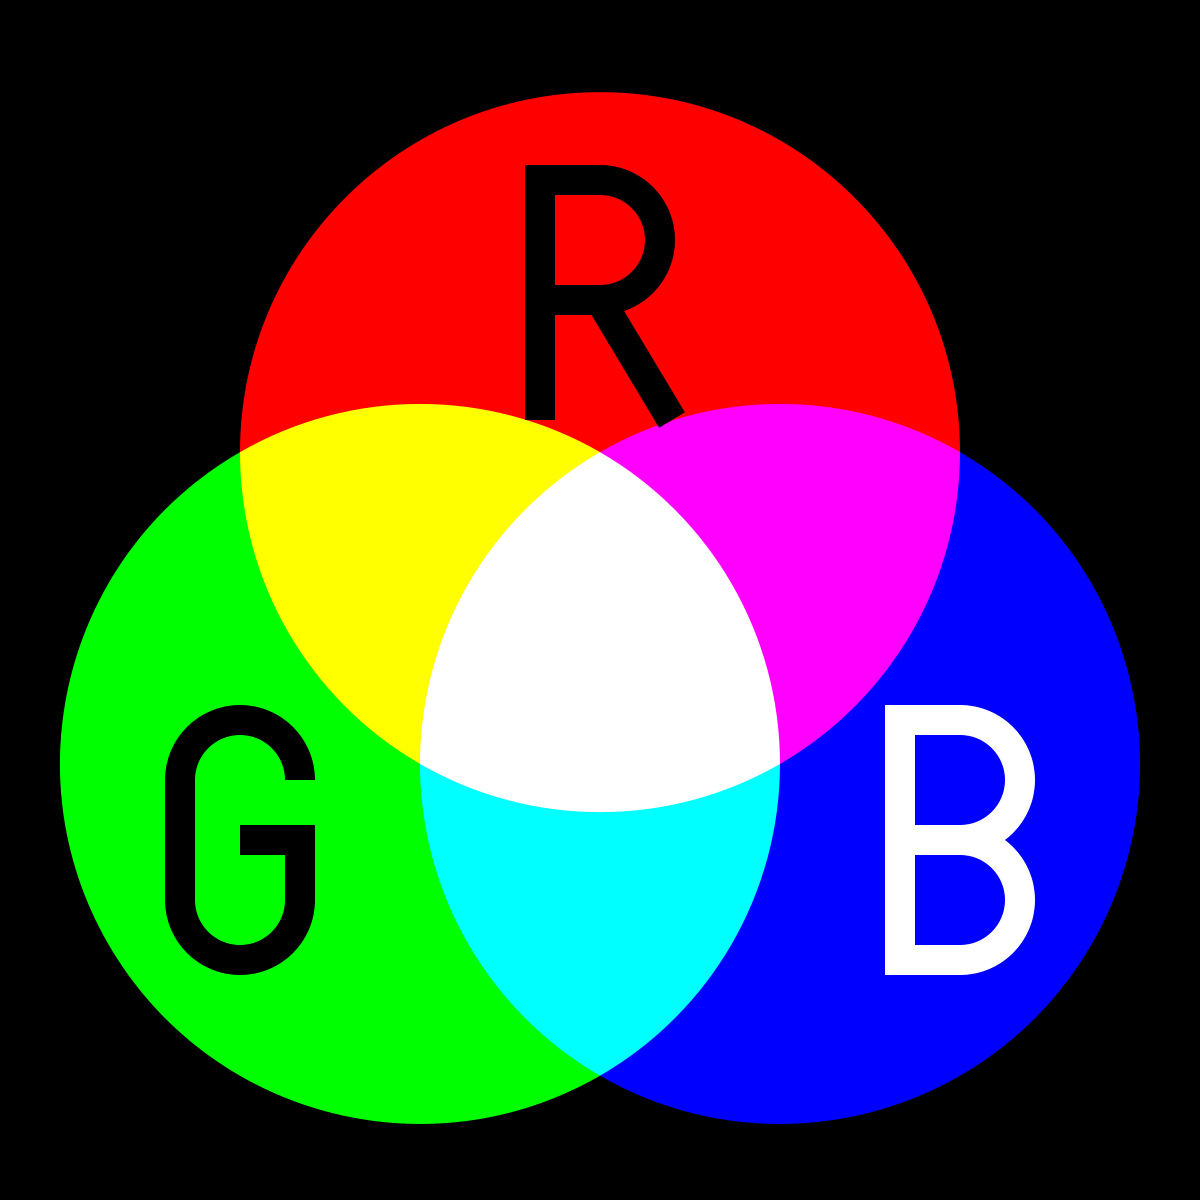

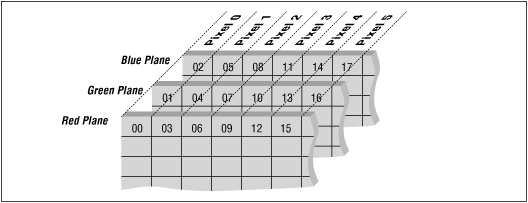

Algumas cores em RGB:
* Vermelho: (255, 0, 0);
* Verde: (0, 255, 0);
* Azul: (0, 0, 255);
* Branco: (255, 255, 255);
* Magenta: (255, 0, 255);
* Amarelo: (255, 255, 0);
* Ciano: (0, 255, 255);
* Preto: (0, 0, 0).

Exemplo com NumPy:

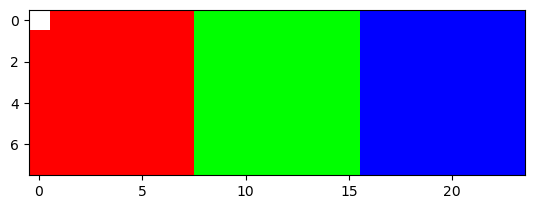

In [ ]:
ex = np.zeros(shape=(8, 8 * 3, 3), dtype=np.uint8) # onde shape é (altura, largura, canais de cor) e dtype é o tipo de dado (uint8 para imagens)
ex[:, :8]   = (255, 0, 0) # todas as linhas, colunas 0:8
ex[:, 8:16] = (0, 255, 0) # todas as linhas, colunas 8:16
ex[:, 16:]  = (0, 0, 255) # todas as linhas, colunas 16:24
ex[0, 0] = (255, 255, 255) # linha 0, coluna 0, todas as páginas 
plt.imshow(ex)

## Imagem binária (binary image)
* É uma imagem onde há somente dois valores possíveis;
* Normalmente preto e branco.
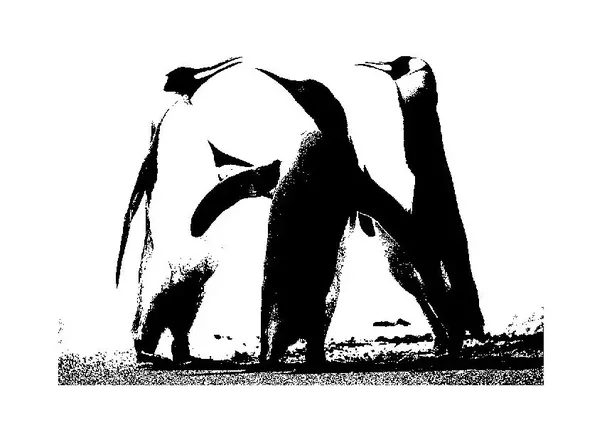

## Imagem em tons de cinza (grayscale image)
* É um bitmap com apenas um canal, representando a iluminação de cada pixel.
* Normalmente utiliza-se padrão de 4 bpp ou 8 bpp.
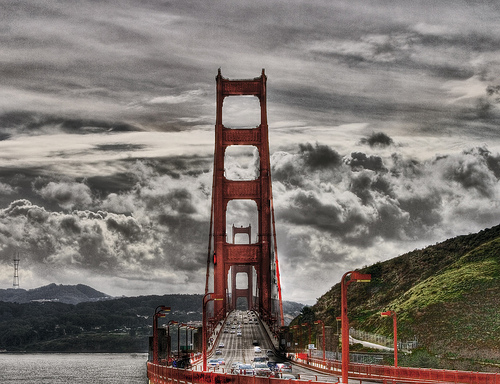 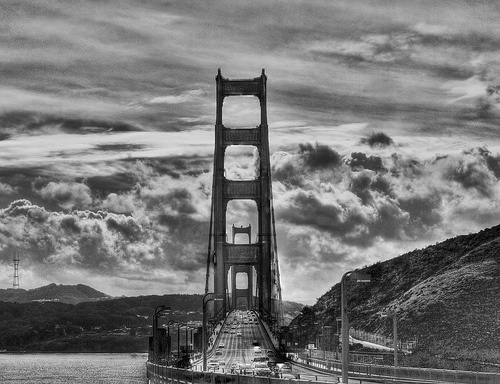

### Métodos de grayscale
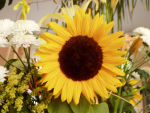
* **Lightness**: média das cores menos proeminentes com as mais proeminentes:
```python
(max(r, g, b) + min(r, g, b)) / 2
```
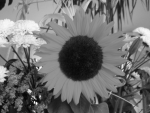
* **Average**: média aritmética simples:
```python
(r + g + b) / 3
```
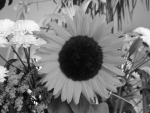
* **Luminosity**: média ponderada onde cada peso é dado de acordo com a percepção humana:

```python
0.2126 * r + 0.7152 * g + 0.0722 * b
```

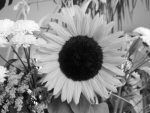

### Grayscale para imagem em tons de cinza

Método **Average** (iterativo):

(192, 192)


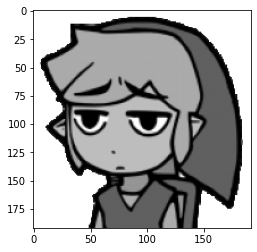

In [ ]:
(l, c, p) = img_np.shape # onde l é a altura, c é a largura e p é o número de canais de cor (RGBA)

img_avg = np.zeros(shape=(l, c), dtype=np.uint8) 
# img_avg é um array numpy com as informações da imagem onde [altura, largura] e dtype é o tipo de dado (uint8 para imagens)
for i in range(l):
    for j in range(c):
        r = float(img_np[i, j, 0]) # linha i, coluna j, página 0 (canal R)
        g = float(img_np[i, j, 1]) # linha i, coluna j, página 1 (canal G)
        b = float(img_np[i, j, 2]) # linha i, coluna j, página 2 (canal B)

        img_avg[i, j] = (r + g + b) / 3 # linha i, coluna j, todas as páginas (média dos canais R, G e B)
        

plt.imshow(img_avg, cmap = 'gray') # cmap é o mapa de cores, onde 'gray' significa escala de cinza (preto e branco)
print(img_avg.shape)

Método **Average** (NumPy, com `np.average`):

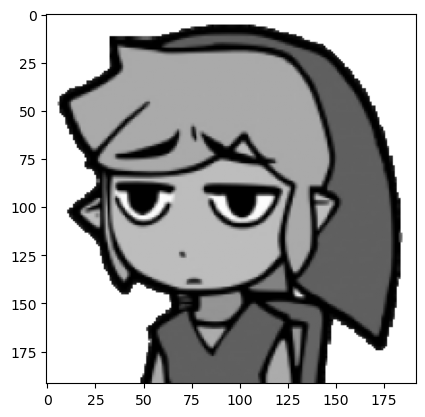

In [ ]:
# Média no eixo 2 (páginas). Canal alpha (A) omitido.
# Obs.: Lembrar de converter para np.uint8!
img_avg2 = np.average(img_np[:, :, :3], axis=2).astype(np.uint8) 
# onde img_np[:, :, :3] significa pegar todas as linhas, todas as colunas e os 3 primeiros canais (R, G, B) 
# e axis=2 significa calcular a média ao longo do eixo 2 (páginas)
plt.imshow(img_avg2, cmap='gray')

Método **Average** (NumPy, com slices):

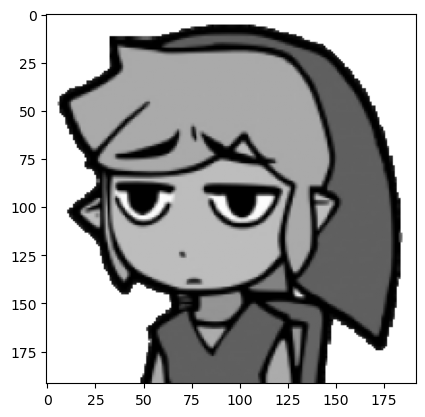

In [ ]:
img_np_float64 = img_np[:, :, :3].astype(np.float64)
# Soma cada pixel das páginas 0, 1 e 2 (R, G, B) e divide por 3, mesma média feita antes
# Obs.: Lembrar de converter para np.uint8!
img_avg3 = ((img_np_float64[:, :, 0] + img_np_float64[:, :, 1] + img_np_float64[:, :, 2]) / 3).astype(np.uint8) 
# onde img_np_float64[:, :, 0] significa pegar todas as linhas, todas as colunas e a página 0 (canal R) e assim por diante para os canais G e B
plt.imshow(img_avg3, cmap='gray')

### Grayscale para imagem binária
Também chamada de **threshold** (limiar):
```
para cada pixel da imagem:
    se o valor em escala de cinza > limiar:
        setar como pixel branco
    senão:
        setar como pixel preto```

## Imagens monocromáticas
* Apresentam tons de apenas uma cor;
* Também é comum se referir às imagens em preto e branco e em tons de cinza como monocromáticas.

Para converter uma imagem RGB em:
1. <font color='red'>Vermelho</font>: zerar canais <font color='green'>G</font> e <font color='blue'>B</font> e usar um método de grayscale em <font color='red'>R</font>;
2. <font color='green'>Verde</font>: zerar canais <font color='red'>R</font> e <font color='blue'>B</font> e usar um método de grayscale em <font color='green'>G</font>;
3. <font color='blue'>Azul</font>: zerar canais <font color='red'>R</font> e <font color='green'>G</font> e usar um método de grayscale em <font color='blue'>B</font>.

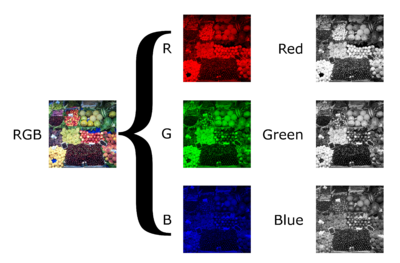

Para gerar imagens monocromáticas a partir de outras:
1. Pegar valor da cor em RGB;
2. Gerar imagens monocromáticas de <font color='red'>vermelho</font>, <font color='green'>verde</font> e <font color='blue'>azul</font>;
3. Misturar (blend) as imagens resultantes usando pesos proporcionais à presença de cada cor.

Exemplo (<font color='purple'>roxo</font>):
1. (<font color='red'>127</font>, <font color='green'>0</font>, <font color='blue'>127</font>);
2. Gerar <font color='red'>img_vermelho</font> e <font color='blue'>img_azul</font>;
3. <font color='purple'>img_roxo</font> = 0.5 * <font color='red'>img_vermelho</font> + 0.5 * <font color='blue'>img_azul</font>.

## Exercícios
Dica para os exercícios: lembre-se de converter para os tipos apropriados (`np.float64`, `np.uint8`) onde for necessário!

1. Utilize um método grayscale e salve a imagem resultante no disco.

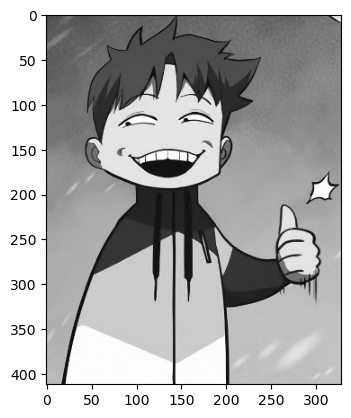

In [24]:
img_up = Image.open('up.png')

img_up_np = np.array(img_up)
plt.imshow(img_up_np)

(l, c, p) = img_up_np.shape # pegando os dados da up
img_up_avg = np.zeros(shape=(l, c), dtype=np.uint8) # imagem com altura e largura da up orignal

for i in range(l):
    for j in range(c):
        r = float(img_up_np[i, j, 0]) # linha i, coluna j, página 0 (canal R)
        g = float(img_up_np[i, j, 1]) # linha i, coluna j, página 1 (canal G)
        b = float(img_up_np[i, j, 2]) # linha i, coluna j, página 2 (canal B)

        img_up_avg[i,j] = (r + g + b) / 3 # fazendo a media de RGB dos pixels da up

plt.imshow(img_up_avg, cmap='gray')

2. Converta uma imagem para binária, utilizando um método de grayscale diferente do anterior. Salve-a no disco.

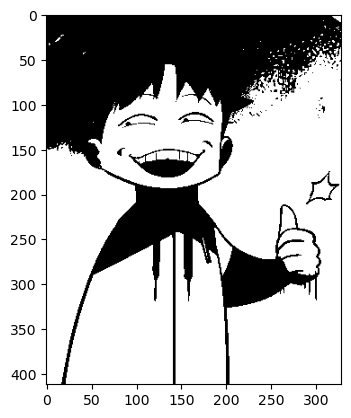

In [25]:
# transformando a imagem up em binária (preto e branco)
img_up_bin = np.zeros(shape=(l, c), dtype=np.uint8) # imagem com altura e largura da up orignal

for i in range(l):
    for j in range(c):
        if img_up_avg[i, j] < 128: # se o pixel for mais escuro que 128 (meio do caminho entre preto e branco)
            img_up_bin[i, j] = 0 # preto
        else:
            img_up_bin[i, j] = 255 # branco

plt.imshow(img_up_bin, cmap='gray')

3. Converta uma imagem para algum espectro monocromático utilizando um método de grayscale diferente dos anteriores. Exiba-a com o matplotlib.

Dica: Caso necessário, uma cópia de uma imagem `img` pode ser feita com `img.copy()`.

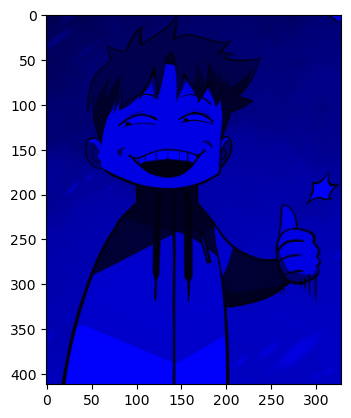

In [ ]:
# convertendo a img up para monocromatica (verde) usando o grayscale

img_up_green = np.zeros(shape=(l, c, 3), dtype=np.uint8) # imagem com altura, largura e 3 canais de cor (RGB)
img_up_blue = np.zeros(shape=(l, c, 3), dtype=np.uint8) # imagem com altura, largura e 3 canais de cor (RGB)
img_up_red = np.zeros(shape=(l, c, 3), dtype=np.uint8) # imagem com altura, largura e 3 canais de cor (RGB)

# zerando os canais R e B e aplicando grayscale em G
# lembrar de testar dps usar outro método de grayscale (o np avg)
for i in range(l):
    for j in range(c):
        r = float(img_up_np[i, j, 0]) # linha i, coluna j, página 0 (canal R)
        g = float(img_up_np[i, j, 1]) # linha i, coluna j, página 1 (canal G)
        b = float(img_up_np[i, j, 2]) # linha i, coluna j, página 2 (canal B)

        gray = (r + g + b) / 3 # fazendo a media de RGB dos pixels da up para obter o valor de cinza

        img_up_green[i, j] = (0, gray, 0) # aplicando o valor de cinza no canal G e zerando os canais R e B
        img_up_blue[i, j] = (0, 0, gray) # aplicando o valor de cinza no canal B e zerando os canais R e G  
        img_up_red[i, j] = (gray, 0, 0) # aplicando o valor de cinza no canal R e zerando os canais G e B  

#plt.imshow(img_up_green)
plt.imshow(img_up_blue)
#plt.imshow(img_up_red)